### Dataset curado con splits fijos; pipeline de carga NIfTI y ventaneo HU funcionando, análisis exploratorio (EDA) de fragmentos por caso; visualizador 1 (MIP raw) implementado y operativo.

In [6]:
from pathlib import Path
import pandas as pd
import SimpleITK as sitk
import nibabel as nib
import numpy as np
import random
import matplotlib.pyplot as plt

In [7]:
BASE_DIR = Path(
    r"C:\Users\annie\proyecto_analitica_corte2"
)

DATA_MHA_DIR = BASE_DIR / "data_mha"

IMAGE_DIRS = sorted(
    DATA_MHA_DIR.glob("PENGWIN_CT_train_images_part*")
)

LABELS_DIR = DATA_MHA_DIR / "PENGWIN_CT_train_labels"

SPLITS_DIR = BASE_DIR / "splits"

SPLITS_DIR.mkdir(exist_ok=True)

In [8]:
image_files = []

for image_dir in IMAGE_DIRS:
    image_files.extend(image_dir.glob("*.mha"))

image_files = sorted(image_files)
label_files = sorted(LABELS_DIR.glob("*.mha"))

print("RESUMEN DEL DATASET")


print(f"Imágenes encontradas: {len(image_files)}")
print(f"Labels encontrados:   {len(label_files)}")

RESUMEN DEL DATASET
Imágenes encontradas: 100
Labels encontrados:   100


In [9]:
image_ids = {
    file.stem
    for file in image_files
}

label_ids = {
    file.stem
    for file in label_files
}

In [10]:
images_without_labels = sorted(image_ids - label_ids)
labels_without_images = sorted(label_ids - image_ids)

common_ids = sorted(image_ids & label_ids)

print("VALIDACIÓN DE CORRESPONDENCIA")

print(f"Casos con imagen + label: {len(common_ids)}")

print(
    f"Imágenes sin label:       {len(images_without_labels)}"
)

print(
    f"Labels sin imagen:        {len(labels_without_images)}"
)


if images_without_labels:
    print("\nImágenes sin label:")
    for case_id in images_without_labels:
        print(f"  - {case_id}")


if labels_without_images:
    print("\nLabels sin imagen:")
    for case_id in labels_without_images:
        print(f"  - {case_id}")


VALIDACIÓN DE CORRESPONDENCIA
Casos con imagen + label: 100
Imágenes sin label:       0
Labels sin imagen:        0


In [11]:
dataset = []

for case_id in common_ids:

    # Buscar la imagen en todas las partes
    image_path = None

    for image_dir in IMAGE_DIRS:
        possible_path = image_dir / f"{case_id}.mha"

        if possible_path.exists():
            image_path = possible_path
            break

    # Ruta del label
    label_path = LABELS_DIR / f"{case_id}.mha"

    # Verificar que ambos existan
    if image_path is not None and label_path.exists():

        dataset.append({
            "case_id": case_id,
            "image_path": str(image_path),
            "label_path": str(label_path)
        })


df = pd.DataFrame(dataset)
df

,case_id,image_path,label_path
0,001,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...
1,002,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...
2,003,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...
3,004,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...
4,005,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...
...,...,...,...
95,096,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...
96,097,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...
97,098,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...
98,099,C:\Users\annie\proyecto_analitica_corte2\data_...,C:\Users\annie\proyecto_analitica_corte2\data_...


In [23]:
dataset_path = SPLITS_DIR / "dataset.csv"

df.to_csv(
    dataset_path,
    index=False
)

print()
print(f"Dataset curado guardado en:")
print(dataset_path)


Dataset curado guardado en:
C:\Users\annie\proyecto_analitica_corte2\splits\dataset.csv


In [12]:
records = []

for _, row in df.iterrows():

    image = sitk.ReadImage(row["image_path"])
    label = sitk.ReadImage(row["label_path"])

    records.append({
        "case_id": row["case_id"],

        # Imagen
        "image_dimension": image.GetDimension(),
        "image_size": image.GetSize(),
        "image_spacing": image.GetSpacing(),

        # Label
        "label_dimension": label.GetDimension(),
        "label_size": label.GetSize(),
        "label_spacing": label.GetSpacing(),

        # Verificaciones
        "same_size": image.GetSize() == label.GetSize(),
        "same_spacing": image.GetSpacing() == label.GetSpacing(),
        "same_direction": image.GetDirection() == label.GetDirection(),
        "same_origin": image.GetOrigin() == label.GetOrigin()
    })

verification_df = pd.DataFrame(records)

verification_df.head(20)

,case_id,image_dimension,image_size,image_spacing,label_dimension,label_size,label_spacing,same_size,same_spacing,same_direction,same_origin
0,001,3,"(512, 512, 401)","(0.78125, 0.78125, 0.800000011920929)",3,"(512, 512, 401)","(0.78125, 0.78125, 0.800000011920929)",True,True,True,True
1,002,3,"(413, 276, 337)","(0.82421875, 0.82421875, 0.800000011920929)",3,"(413, 276, 337)","(0.82421875, 0.82421875, 0.800000011920929)",True,True,True,True
2,003,3,"(512, 381, 285)","(0.759765625, 0.759765625, 1.0)",3,"(512, 381, 285)","(0.759765625, 0.759765625, 1.0)",True,True,True,True
3,004,3,"(386, 254, 224)","(0.84375, 0.84375, 1.0)",3,"(386, 254, 224)","(0.84375, 0.84375, 1.0)",True,True,True,True
4,005,3,"(512, 512, 312)","(0.896484375, 0.896484375, 1.0)",3,"(512, 512, 312)","(0.896484375, 0.896484375, 1.0)",True,True,True,True
5,006,3,"(426, 279, 283)","(0.8125, 0.8125, 1.0)",3,"(426, 279, 283)","(0.8125, 0.8125, 1.0)",True,True,True,True
6,007,3,"(512, 512, 317)","(0.8359375, 0.8359375, 1.0)",3,"(512, 512, 317)","(0.8359375, 0.8359375, 1.0)",True,True,True,True
7,008,3,"(512, 512, 335)","(0.7421875, 0.7421875, 0.800000011920929)",3,"(512, 512, 335)","(0.7421875, 0.7421875, 0.800000011920929)",True,True,True,True
8,009,3,"(415, 245, 303)","(0.8125, 0.8125, 0.8000000715255737)",3,"(415, 245, 303)","(0.8125, 0.8125, 0.8000000715255737)",True,True,True,True
9,010,3,"(512, 512, 350)","(0.9459999799728394, 0.9459999799728394, 0.798...",3,"(512, 512, 350)","(0.9459999799728394, 0.9459999799728394, 0.798...",True,True,True,True


In [13]:
print("Casos:", len(verification_df))

print("\nDimensiones de las imágenes:")
print(verification_df["image_dimension"].value_counts())

print("\nDimensiones de los labels:")
print(verification_df["label_dimension"].value_counts())

print("\nTamaños CT-label iguales:")
print(verification_df["same_size"].value_counts())

print("\nSpacing CT-label iguales:")
print(verification_df["same_spacing"].value_counts())

Casos: 100

Dimensiones de las imágenes:
image_dimension
3    100
Name: count, dtype: int64

Dimensiones de los labels:
label_dimension
3    100
Name: count, dtype: int64

Tamaños CT-label iguales:
same_size
True    100
Name: count, dtype: int64

Spacing CT-label iguales:
same_spacing
True    100
Name: count, dtype: int64


### mha -> NIfTI (nii.gz)

In [14]:
BASE_DIR = Path(r"C:\Users\annie\proyecto_analitica_corte2")

NIFTI_IMAGES_DIR = BASE_DIR / "data" / "nifti_images"
NIFTI_LABELS_DIR = BASE_DIR / "data" / "nifti_labels"

NIFTI_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
NIFTI_LABELS_DIR.mkdir(parents=True, exist_ok=True)

print("Carpeta de imágenes:", NIFTI_IMAGES_DIR)
print("Carpeta de labels:", NIFTI_LABELS_DIR)

Carpeta de imágenes: C:\Users\annie\proyecto_analitica_corte2\data\nifti_images
Carpeta de labels: C:\Users\annie\proyecto_analitica_corte2\data\nifti_labels


In [15]:
conversion_records = []
convertidos = 0
saltados = 0

for _, row in df.iterrows():

    case_id = row["case_id"]

    image_mha = row["image_path"]
    label_mha = row["label_path"]

    image_nii = NIFTI_IMAGES_DIR / f"{case_id}.nii.gz"
    label_nii = NIFTI_LABELS_DIR / f"{case_id}.nii.gz"

    # Si ambos archivos NIfTI ya existen, no los regeneres
    if image_nii.exists() and label_nii.exists():
        saltados += 1
    else:
        image = sitk.ReadImage(image_mha)
        label = sitk.ReadImage(label_mha)

        sitk.WriteImage(image, str(image_nii), useCompression=True)
        sitk.WriteImage(label, str(label_nii), useCompression=True)
        convertidos += 1

    conversion_records.append({
        "case_id": case_id,
        "image_path": str(image_nii),
        "label_path": str(label_nii)
    })

nifti_df = pd.DataFrame(conversion_records)

print(f"Convertidos ahora: {convertidos}")
print(f"Ya existían (saltados): {saltados}")
print(f"Total en nifti_df: {len(nifti_df)}")
print(nifti_df.head())

Convertidos ahora: 0
Ya existían (saltados): 100
Total en nifti_df: 100
  case_id                                         image_path  \
0     001  C:\Users\annie\proyecto_analitica_corte2\data\...   
1     002  C:\Users\annie\proyecto_analitica_corte2\data\...   
2     003  C:\Users\annie\proyecto_analitica_corte2\data\...   
3     004  C:\Users\annie\proyecto_analitica_corte2\data\...   
4     005  C:\Users\annie\proyecto_analitica_corte2\data\...   

                                          label_path  
0  C:\Users\annie\proyecto_analitica_corte2\data\...  
1  C:\Users\annie\proyecto_analitica_corte2\data\...  
2  C:\Users\annie\proyecto_analitica_corte2\data\...  
3  C:\Users\annie\proyecto_analitica_corte2\data\...  
4  C:\Users\annie\proyecto_analitica_corte2\data\...  


In [16]:
verification_nifti = []

for _, row in nifti_df.iterrows():

    image = sitk.ReadImage(row["image_path"])
    label = sitk.ReadImage(row["label_path"])

    verification_nifti.append({
        "case_id": row["case_id"],
        "image_dimension": image.GetDimension(),
        "label_dimension": label.GetDimension(),
        "image_size": image.GetSize(),
        "label_size": label.GetSize(),
        "image_spacing": image.GetSpacing(),
        "label_spacing": label.GetSpacing(),
        "same_size": image.GetSize() == label.GetSize(),
        "same_spacing": image.GetSpacing() == label.GetSpacing()
    })

nifti_verification_df = pd.DataFrame(verification_nifti)

print(nifti_verification_df.head())

  case_id  image_dimension  label_dimension       image_size       label_size  \
0     001                3                3  (512, 512, 401)  (512, 512, 401)   
1     002                3                3  (413, 276, 337)  (413, 276, 337)   
2     003                3                3  (512, 381, 285)  (512, 381, 285)   
3     004                3                3  (386, 254, 224)  (386, 254, 224)   
4     005                3                3  (512, 512, 312)  (512, 512, 312)   

                                 image_spacing  \
0        (0.78125, 0.78125, 0.800000011920929)   
1  (0.82421875, 0.82421875, 0.800000011920929)   
2              (0.759765625, 0.759765625, 1.0)   
3                      (0.84375, 0.84375, 1.0)   
4              (0.896484375, 0.896484375, 1.0)   

                                 label_spacing  same_size  same_spacing  
0        (0.78125, 0.78125, 0.800000011920929)       True          True  
1  (0.82421875, 0.82421875, 0.800000011920929)       True       

In [17]:
print("Dimensiones de imágenes:")
print(nifti_verification_df["image_dimension"].value_counts())

print("\nDimensiones de labels:")
print(nifti_verification_df["label_dimension"].value_counts())

print("\nTamaños iguales:")
print(nifti_verification_df["same_size"].value_counts())

print("\nSpacing iguales:")
print(nifti_verification_df["same_spacing"].value_counts())

Dimensiones de imágenes:
image_dimension
3    100
Name: count, dtype: int64

Dimensiones de labels:
label_dimension
3    100
Name: count, dtype: int64

Tamaños iguales:
same_size
True    100
Name: count, dtype: int64

Spacing iguales:
same_spacing
True    100
Name: count, dtype: int64


In [13]:
DATASET_NIFTI_CSV = BASE_DIR / "dataset_nifti.csv"

nifti_df.to_csv(DATASET_NIFTI_CSV, index=False)

print("Dataset NIfTI guardado en:")
print(DATASET_NIFTI_CSV)

Dataset NIfTI guardado en:
C:\Users\annie\proyecto_analitica_corte2\dataset_nifti.csv


In [18]:

frag_counts = []

for _, row in nifti_df.iterrows():
    label_img = nib.load(row["label_path"])
    label_vol = label_img.get_fdata()
    n_fragments = len(np.unique(label_vol)) - 1  # -1 por excluir el fondo (label 0)
    frag_counts.append(n_fragments)

nifti_df["n_fragments"] = frag_counts

print("Distribución de número de fragmentos por caso:")
print(nifti_df["n_fragments"].describe())
print("\nConteo de valores (cuántos casos tienen cada n° de fragmentos):")
print(nifti_df["n_fragments"].value_counts().sort_index())

Distribución de número de fragmentos por caso:
count    100.000000
mean       5.750000
std        1.217507
min        3.000000
25%        5.000000
50%        6.000000
75%        7.000000
max        9.000000
Name: n_fragments, dtype: float64

Conteo de valores (cuántos casos tienen cada n° de fragmentos):
n_fragments
3     1
4    13
5    32
6    28
7    18
8     6
9     2
Name: count, dtype: int64


In [19]:

SEED = 42
case_ids = nifti_df["case_id"].tolist()

random.seed(SEED)
random.shuffle(case_ids)

n = len(case_ids)
n_train = int(n * 0.70)
n_val = int(n * 0.15)

splits = {
    "train": case_ids[:n_train],
    "val": case_ids[n_train:n_train + n_val],
    "test": case_ids[n_train + n_val:],
}

for name, ids in splits.items():
    (SPLITS_DIR / f"{name}.txt").write_text("\n".join(ids))

print({k: len(v) for k, v in splits.items()})

{'train': 70, 'val': 15, 'test': 15}


In [20]:

def load_nifti(path):
    img = nib.load(path)
    volume = img.get_fdata()
    spacing = img.header.get_zooms()  # (x, y, z) en mm
    return volume, spacing

def apply_hu_window(volume, window_center=400, window_width=1800):
    low = window_center - window_width / 2
    high = window_center + window_width / 2
    windowed = np.clip(volume, low, high)
    windowed = (windowed - low) / (high - low)
    return windowed

# prueba rápida sobre un caso
volume, spacing = load_nifti(nifti_df.loc[0, "image_path"])
windowed = apply_hu_window(volume)
print(f"Caso {nifti_df.loc[0, 'case_id']}: spacing={spacing}, "
      f"rango original=({volume.min():.1f}, {volume.max():.1f}), "
      f"rango ventaneado=({windowed.min():.2f}, {windowed.max():.2f})")

Caso 001: spacing=(np.float32(0.78125), np.float32(0.78125), np.float32(0.8)), rango original=(-1023.0, 2775.0), rango ventaneado=(0.00, 1.00)


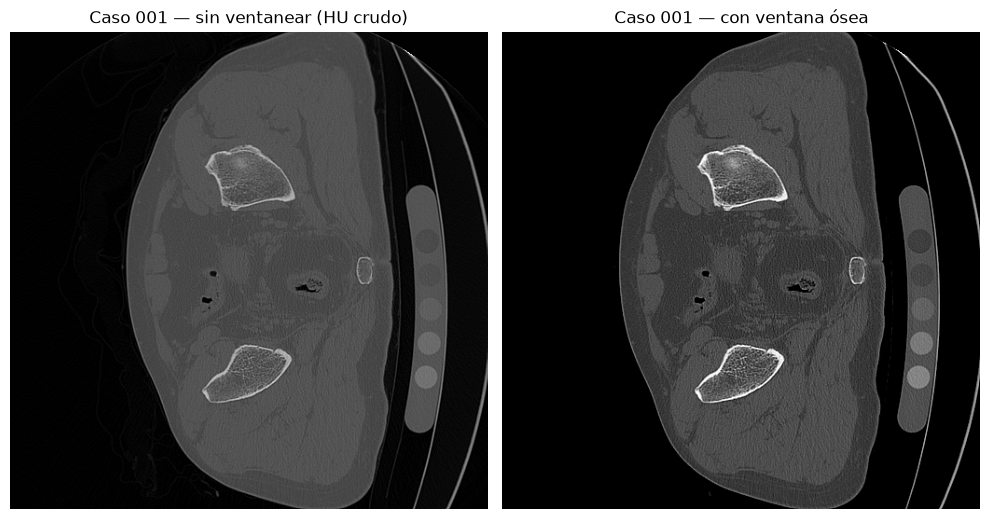

In [21]:
case_id = "001"
row = nifti_df[nifti_df["case_id"] == case_id].iloc[0]

volume, spacing = load_nifti(row["image_path"])
windowed = apply_hu_window(volume)

# corte del medio del volumen (eje Z)
mid_slice = volume.shape[2] // 2  # con nibabel el eje Z suele ser el último

fig, axes = plt.subplots(1, 2, figsize=(10, 10))

axes[0].imshow(volume[:, :, mid_slice], cmap="gray")
axes[0].set_title(f"Caso {case_id} — sin ventanear (HU crudo)")
axes[0].axis("off")

axes[1].imshow(windowed[:, :, mid_slice], cmap="gray")
axes[1].set_title(f"Caso {case_id} — con ventana ósea")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
def label_to_region(label):
    if label == 0:
        return "background"
    elif 1 <= label <= 10:
        return "sacro"
    elif 11 <= label <= 20:
        return "coxal_izquierdo"
    elif 21 <= label <= 30:
        return "coxal_derecho"
    else:
        return "desconocido"

fragment_rows = []

for _, row in nifti_df.iterrows():
    label_img = nib.load(row["label_path"])
    label_vol = label_img.get_fdata()
    spacing = tuple(float(x) for x in label_img.header.get_zooms())
    voxel_volume_mm3 = spacing[0] * spacing[1] * spacing[2]

    labels_present = np.unique(label_vol)
    labels_present = labels_present[labels_present != 0]  # excluir fondo

    for lab in labels_present:
        n_voxels = int(np.sum(label_vol == lab))
        fragment_rows.append({
            "case_id": row["case_id"],
            "label": int(lab),
            "region": label_to_region(int(lab)),
            "n_voxels": n_voxels,
            "volume_mm3": n_voxels * voxel_volume_mm3,
        })

frag_df = pd.DataFrame(fragment_rows)
frag_df.to_csv(BASE_DIR / "metadata_fragments.csv", index=False)
print(f"Total de fragmentos individuales en el dataset: {len(frag_df)}")
frag_df.head(10)

Total de fragmentos individuales en el dataset: 575


,case_id,label,region,n_voxels,volume_mm3
0,001,1,sacro,458539,223895.999430
1,001,11,coxal_izquierdo,762194,372165.044608
2,001,12,coxal_izquierdo,63957,31229.004372
3,001,21,coxal_derecho,844349,412279.791300
4,002,1,sacro,323928,176044.906041
5,002,2,sacro,39087,21242.582433
6,002,11,coxal_izquierdo,502549,273119.926299
7,002,21,coxal_derecho,470491,255697.389198
8,002,22,coxal_derecho,15260,8293.340700
9,002,23,coxal_derecho,19132,10397.653622


In [23]:
print("=== RESUMEN GENERAL ===")
print(f"Total de fragmentos (todas las regiones, todos los casos): {len(frag_df)}")
print(f"Fragmentos por caso -> min: {frag_df.groupby('case_id').size().min()}, "
      f"max: {frag_df.groupby('case_id').size().max()}, "
      f"media: {frag_df.groupby('case_id').size().mean():.2f}")

print("\n=== DISTRIBUCIÓN POR REGIÓN ANATÓMICA ===")
print(frag_df["region"].value_counts())

print("\n=== FRAGMENTOS POR REGIÓN, POR CASO (promedio) ===")
frag_por_region_caso = frag_df.groupby(["case_id", "region"]).size().reset_index(name="n_fragmentos")
print(frag_por_region_caso.groupby("region")["n_fragmentos"].describe())

=== RESUMEN GENERAL ===
Total de fragmentos (todas las regiones, todos los casos): 575
Fragmentos por caso -> min: 3, max: 9, media: 5.75

=== DISTRIBUCIÓN POR REGIÓN ANATÓMICA ===
region
coxal_izquierdo    215
coxal_derecho      207
sacro              153
Name: count, dtype: int64

=== FRAGMENTOS POR REGIÓN, POR CASO (promedio) ===
                 count  mean       std  min  25%  50%  75%  max
region                                                         
coxal_derecho    100.0  2.07  0.987344  1.0  1.0  2.0  3.0  4.0
coxal_izquierdo  100.0  2.15  1.067187  1.0  1.0  2.0  3.0  6.0
sacro            100.0  1.53  0.658357  1.0  1.0  1.0  2.0  4.0


In [24]:
print("=== VOLUMEN DE FRAGMENTOS (mm³) ===")
print(frag_df["volume_mm3"].describe())

# Fragmentos sospechosamente pequeños (posible ruido de anotación vs. fragmento real)
umbral_pequeno = frag_df["volume_mm3"].quantile(0.05)  # percentil 5 más chico
pequenos = frag_df[frag_df["volume_mm3"] < umbral_pequeno]
print(f"\nFragmentos por debajo del percentil 5 de volumen (<{umbral_pequeno:.1f} mm³): {len(pequenos)}")
print(pequenos[["case_id", "region", "label", "volume_mm3"]].sort_values("volume_mm3").head(10))

=== VOLUMEN DE FRAGMENTOS (mm³) ===
count       575.000000
mean     135836.241955
std      114659.517155
min         282.212597
25%       23250.124644
50%      128182.935724
75%      234834.021490
max      416131.106541
Name: volume_mm3, dtype: float64

Fragmentos por debajo del percentil 5 de volumen (<3145.0 mm³): 29
    case_id           region  label   volume_mm3
299     052    coxal_derecho     23   282.212597
482     085            sacro      2   313.483475
215     038    coxal_derecho     23   518.747187
430     075  coxal_izquierdo     13   641.070251
329     057  coxal_izquierdo     13   683.141804
122     023  coxal_izquierdo     12   807.295788
478     084  coxal_izquierdo     14   812.787437
205     037            sacro      2   947.445813
477     084  coxal_izquierdo     13  1040.887642
312     054    coxal_derecho     24  1190.747253


In [25]:
def get_main_fragment_per_bone(frag_df):
    rows = []
    for (case_id, region), group in frag_df.groupby(["case_id", "region"]):
        if region == "background":
            continue
        main_frag = group.loc[group["volume_mm3"].idxmax()]
        rows.append({
            "case_id": case_id,
            "region": region,
            "main_label": main_frag["label"],
            "main_volume_mm3": main_frag["volume_mm3"],
            "n_fragmentos_totales": len(group),
            "n_fragmentos_conminutos": len(group) - 1,
        })
    return pd.DataFrame(rows)

main_frag_df = get_main_fragment_per_bone(frag_df)
main_frag_df.to_csv(BASE_DIR / "main_fragments.csv", index=False)
main_frag_df.head(10)

,case_id,region,main_label,main_volume_mm3,n_fragmentos_totales,n_fragmentos_conminutos
0,001,coxal_derecho,21,412279.791300,1,0
1,001,coxal_izquierdo,11,372165.044608,2,1
2,001,sacro,1,223895.999430,1,0
3,002,coxal_derecho,21,255697.389198,3,2
4,002,coxal_izquierdo,11,273119.926299,1,0
5,002,sacro,1,176044.906041,2,1
6,003,coxal_derecho,21,281041.536819,1,0
7,003,coxal_izquierdo,11,236036.146324,4,3
8,003,sacro,1,181401.174675,1,0
9,004,coxal_derecho,21,214046.217773,2,1


In [26]:
print("=== HUESOS SIN FRACTURA (un solo fragmento) POR REGIÓN ===")
sin_fractura = main_frag_df[main_frag_df["n_fragmentos_totales"] == 1]
print(sin_fractura["region"].value_counts())

print("\n=== % de huesos fracturados por región ===")
total_por_region = main_frag_df["region"].value_counts()
fracturados_por_region = main_frag_df[main_frag_df["n_fragmentos_totales"] > 1]["region"].value_counts()
pct_fracturado = (fracturados_por_region / total_por_region * 100).round(1)
print(pct_fracturado)

=== HUESOS SIN FRACTURA (un solo fragmento) POR REGIÓN ===
region
sacro              55
coxal_derecho      36
coxal_izquierdo    34
Name: count, dtype: int64

=== % de huesos fracturados por región ===
region
coxal_derecho      64.0
coxal_izquierdo    66.0
sacro              45.0
Name: count, dtype: float64


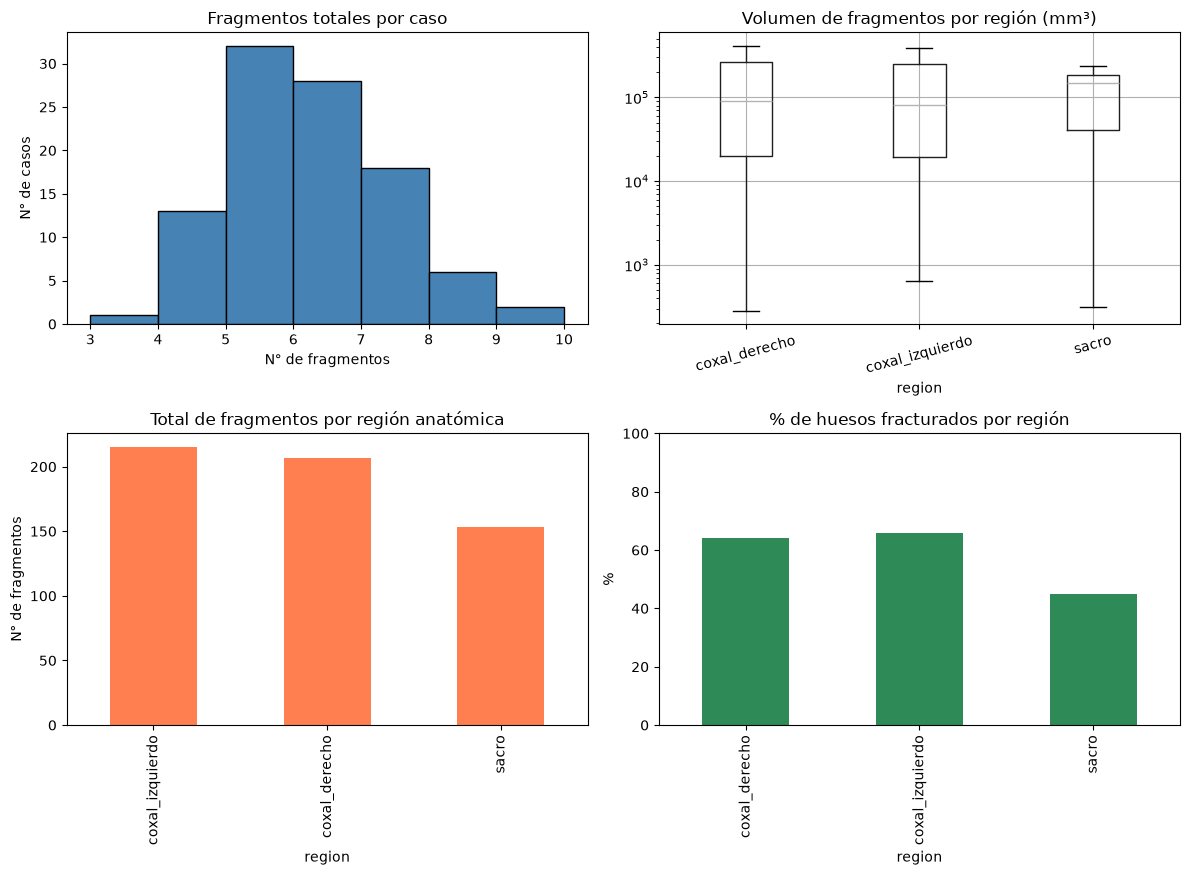

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Histograma: n° de fragmentos por caso (a nivel dataset completo)
frag_por_caso = frag_df.groupby("case_id").size()
axes[0, 0].hist(frag_por_caso, bins=range(frag_por_caso.min(), frag_por_caso.max() + 2), 
                 edgecolor="black", color="steelblue")
axes[0, 0].set_title("Fragmentos totales por caso")
axes[0, 0].set_xlabel("N° de fragmentos")
axes[0, 0].set_ylabel("N° de casos")

# Boxplot: volumen de fragmento por región
frag_df.boxplot(column="volume_mm3", by="region", ax=axes[0, 1])
axes[0, 1].set_title("Volumen de fragmentos por región (mm³)")
axes[0, 1].set_yscale("log")  # log porque probablemente hay outliers grandes
plt.sca(axes[0, 1])
plt.xticks(rotation=15)

# Barras: cantidad de fragmentos por región (total dataset)
frag_df["region"].value_counts().plot(kind="bar", ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Total de fragmentos por región anatómica")
axes[1, 0].set_ylabel("N° de fragmentos")

# Barras: % de huesos fracturados por región
pct_fracturado.plot(kind="bar", ax=axes[1, 1], color="seagreen")
axes[1, 1].set_title("% de huesos fracturados por región")
axes[1, 1].set_ylabel("%")
axes[1, 1].set_ylim(0, 100)

plt.suptitle("")  # quita el título automático feo que pone pandas
plt.tight_layout()
plt.show()

In [ ]:
#visualizador 

In [28]:
def compute_mip(volume, hu_threshold=300, axis=2):
    """
    Proyección de máxima intensidad, mostrando solo hueso (HU > umbral).
    axis=2 -> proyección axial (mirando desde arriba/abajo, eje Z con nibabel)
    axis=1 -> proyección coronal (mirando de frente)
    axis=0 -> proyección sagital (mirando de lado)
    """
    bone_only = np.where(volume > hu_threshold, volume, 0)

    mip = np.max(bone_only, axis=axis)
    return mip

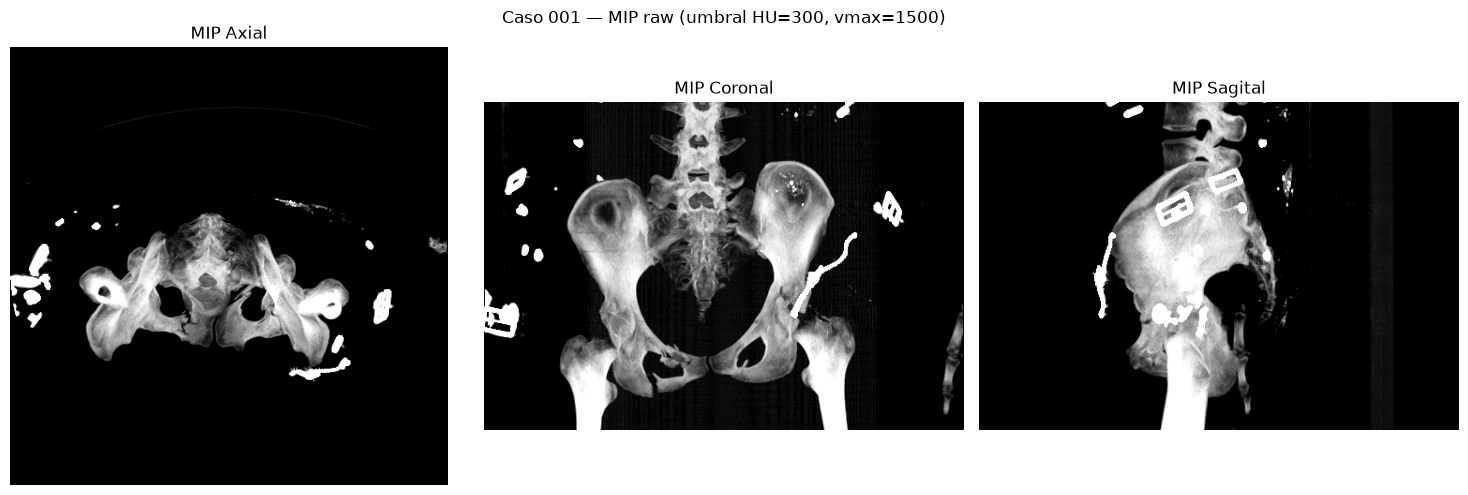

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

mip_axial = compute_mip(volume, hu_threshold=300, axis=2)
mip_coronal = compute_mip(volume, hu_threshold=300, axis=1)
mip_sagital = compute_mip(volume, hu_threshold=300, axis=0)

# vmax limitado al rango típico de hueso, NO al máximo real del volumen (que incluye metal)
vmax_hueso = 1500

axes[0].imshow(mip_axial.T, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[0].set_title("MIP Axial")
axes[0].axis("off")

axes[1].imshow(mip_coronal.T, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[1].set_title("MIP Coronal")
axes[1].axis("off")

axes[2].imshow(mip_sagital.T, cmap="gray", origin="lower", vmin=300, vmax=vmax_hueso)
axes[2].set_title("MIP Sagital")
axes[2].axis("off")

plt.suptitle(f"Caso {case_id} — MIP raw (umbral HU=300, vmax={vmax_hueso})")
plt.tight_layout()
plt.show()